# Medidas de Heterogeneidad

**Almacenes y Minería de Datos — Facultad de Ciencias, UNAM**

Partimos del dataset ya limpio de la Práctica 3 (`data/data-processed/endireh_2021_limpio.csv`).
No se vuelve a descargar ni reestructurar el proyecto — se extiende la arquitectura existente.

## Paso 2: Medidas de Heterogeneidad

Vamos calcular tres índices de heterogeneidad/diversidad sobre una variable cualitativa:
el **Índice de Variación Cualitativa (IQV)**, el **índice de Gini-Simpson** y la
**entropía de Shannon**.

**Variable elegida: `nivel_escolaridad`.** Elegimos `nivel_escolaridad`
porque tiene pocas categorías (6, de A1 a C2), no tiene valores nulos, y es
temáticamente relevante para el análisis.


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import polars as pl
from config.rutas import RUTA_DATA_PROCESSED, ARCHIVO_ENDIREH_LIMPIO, RUTA_REPORTS_FIGURES
from src.models.heterogeneidad import (
    calcular_gini_simpson, calcular_iqv, calcular_entropia_shannon, obtener_proporciones,
)
from src.visualization.graficas import graficar_barras_heterogeneidad

df = pl.read_csv(RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_LIMPIO)
print("Filas:", df.shape[0])

Filas: 105753


### Distribución de `nivel_escolaridad`

Antes de calcular los índices, vemos cómo se reparten las categorías.

In [2]:
conteo_escolaridad = df["nivel_escolaridad"].value_counts().sort("nivel_escolaridad")
conteo_escolaridad = conteo_escolaridad.with_columns(
    (pl.col("count") / pl.col("count").sum() * 100).round(1).alias("pct")
)
conteo_escolaridad

nivel_escolaridad,count,pct
str,u32,f64
"""A1""",61977,58.6
"""A2""",2399,2.3
"""B1""",12597,11.9
"""B2""",9549,9.0
"""C1""",14458,13.7
"""C2""",4773,4.5


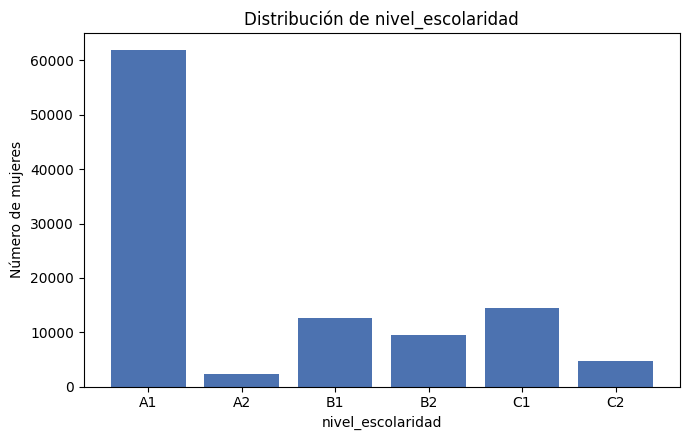

In [3]:
fig = graficar_barras_heterogeneidad(df, "nivel_escolaridad", ruta_salida=str(RUTA_REPORTS_FIGURES / "barras_heterogeneidad_escolaridad.png"))

**Interpretación de la gráfica:** `A1` concentra el 58.6% de las encuestadas,
lo que es muy por encima de las demás categorías. A simple vista ya se nota que la
distribución no es uniforme. Los índices que siguen cuantifican exactamente
qué tan heterogénea es esta distribución.

In [4]:
gs = calcular_gini_simpson(df, "nivel_escolaridad")
iqv = calcular_iqv(df, "nivel_escolaridad")
shannon = calcular_entropia_shannon(df, "nivel_escolaridad")

print(f"Gini-Simpson: {gs:.4f}  (0 = sin diversidad, 1 = máxima diversidad)")
print(f"IQV: {iqv:.4f}  (0 = sin diversidad, 1 = máxima diversidad)")
print(f"Entropía de Shannon (H): {shannon['H']:.4f} bits")
print(f"H máxima posible: {shannon['H_max']:.4f} bits (log2(6), con 6 categorías)")
print(f"Uniformidad relativa: {shannon['uniformidad_relativa']:.4f}  (H / H_max)")

Gini-Simpson: 0.6130  (0 = sin diversidad, 1 = máxima diversidad)
IQV: 0.7355  (0 = sin diversidad, 1 = máxima diversidad)
Entropía de Shannon (H): 1.8488 bits
H máxima posible: 2.5850 bits (log2(6), con 6 categorías)
Uniformidad relativa: 0.7152  (H / H_max)


**Interpretación:** hay heterogeneidad moderada, no nula pero tampoco máxima. El Gini-Simpson (0.61) y
el IQV (0.74, ya normalizado a la escala 0-1) indican que, aunque `A1` domina,
las otras 5 categorías sí tienen presencia real. La entropía de Shannon confirma
que se observan 1.85 de los 2.58 bits máximos posibles con 6 categorías
igualmente probables, es decir, una uniformidad relativa del 71.5%  ya es bastante
heterogénea, pero no perfectamente pareja debido al peso de `A1`.

### Comparación con otra variable

Para dimensionar mejor estos números, los comparamos contra `sufrio_violencia_pareja`,
una variable binaria donde sabemos de antemano que hay bastante concentración
(mayoría "No").

In [5]:
gs_viol = calcular_gini_simpson(df, "sufrio_violencia_pareja")
iqv_viol = calcular_iqv(df, "sufrio_violencia_pareja")
shannon_viol = calcular_entropia_shannon(df, "sufrio_violencia_pareja")

print(f"sufrio_violencia_pareja -> Gini-Simpson: {gs_viol:.4f} | IQV: {iqv_viol:.4f} | "
      f"H: {shannon_viol['H']:.4f} / {shannon_viol['H_max']:.4f} bits "
      f"(uniformidad: {shannon_viol['uniformidad_relativa']:.4f})")

sufrio_violencia_pareja -> Gini-Simpson: 0.2972 | IQV: 0.5944 | H: 0.6835 / 1.0000 bits (uniformidad: 0.6835)


**Interpretación:** como se esperaba, `sufrio_violencia_pareja` tiene índices
de heterogeneidad bastante más bajos que `nivel_escolaridad` ya que solo tiene solo 2
categorías y una de ellas domina fuertemente. Esto confirma que los índices
sí distinguen correctamente entre una variable más repartida (`nivel_escolaridad`)
y una más concentrada (`sufrio_violencia_pareja`), que es justo lo que estas
medidas deben capturar